# ASSIGNMENT 4

In [1]:
import numpy  as np
import pandas as pd
import matplotlib.pyplot as plt

import statsmodels.formula.api as smf
import linearmodels.iv as iv

In [2]:
randhour=11

In [3]:
df = pd.read_csv('elmarket.csv', parse_dates=['time','date'])
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 35112 entries, 0 to 35111
Data columns (total 17 columns):
 #   Column      Non-Null Count  Dtype         
---  ------      --------------  -----         
 0   time        35112 non-null  datetime64[ns]
 1   date        35112 non-null  datetime64[ns]
 2   year        35112 non-null  int64         
 3   week        35112 non-null  int64         
 4   day         35112 non-null  int64         
 5   hour        35112 non-null  int64         
 6   price       35112 non-null  float64       
 7   cons        35112 non-null  int64         
 8   prod        35112 non-null  int64         
 9   res_level   35112 non-null  int64         
 10  norm_level  35112 non-null  int64         
 11  se_nuc      35112 non-null  int64         
 12  p_oil       35112 non-null  float64       
 13  p_co2       35112 non-null  float64       
 14  temp_osl    35112 non-null  float64       
 15  dholi       35112 non-null  int64         
 16  dwkday      35112 non-

In [4]:
df

,time,date,year,week,day,hour,price,cons,prod,res_level,norm_level,se_nuc,p_oil,p_co2,temp_osl,dholi,dwkday
0,2006-01-09 00:00:00,2006-01-09,2006,2,1,0,39.17,12130,11941,4211,3602,96,442.85,251.26,-2.5,0,1
1,2006-01-09 01:00:00,2006-01-09,2006,2,1,1,38.63,11845,10796,4211,3602,96,442.85,251.26,-2.5,0,1
2,2006-01-09 02:00:00,2006-01-09,2006,2,1,2,38.01,11706,10213,4211,3602,96,442.85,251.26,-2.5,0,1
3,2006-01-09 03:00:00,2006-01-09,2006,2,1,3,37.81,11700,9989,4211,3602,96,442.85,251.26,-2.5,0,1
4,2006-01-09 04:00:00,2006-01-09,2006,2,1,4,38.21,11843,10532,4211,3602,96,442.85,251.26,-2.7,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
35107,2010-01-10 19:00:00,2010-01-10,2010,1,7,19,49.23,18684,16535,3633,3827,66,451.60,124.90,-13.1,0,0
35108,2010-01-10 20:00:00,2010-01-10,2010,1,7,20,46.56,18573,15267,3633,3827,66,451.60,124.90,-13.8,0,0
35109,2010-01-10 21:00:00,2010-01-10,2010,1,7,21,45.98,18242,14352,3633,3827,67,451.60,124.90,-15.0,0,0
35110,2010-01-10 22:00:00,2010-01-10,2010,1,7,22,45.37,17759,13322,3633,3827,66,451.60,124.90,-14.6,0,0


In [5]:
#
# select observations only for a specific hour
#
df = df[df['hour']==randhour]

#
# set index and sort
df = df.set_index(['date']).sort_index().copy()

df.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 1463 entries, 2006-01-09 to 2010-01-10
Data columns (total 16 columns):
 #   Column      Non-Null Count  Dtype         
---  ------      --------------  -----         
 0   time        1463 non-null   datetime64[ns]
 1   year        1463 non-null   int64         
 2   week        1463 non-null   int64         
 3   day         1463 non-null   int64         
 4   hour        1463 non-null   int64         
 5   price       1463 non-null   float64       
 6   cons        1463 non-null   int64         
 7   prod        1463 non-null   int64         
 8   res_level   1463 non-null   int64         
 9   norm_level  1463 non-null   int64         
 10  se_nuc      1463 non-null   int64         
 11  p_oil       1463 non-null   float64       
 12  p_co2       1463 non-null   float64       
 13  temp_osl    1463 non-null   float64       
 14  dholi       1463 non-null   int64         
 15  dwkday      1463 non-null   int64         
dtypes: dat

In [6]:
# Applying log transformations
df['log_price'] = np.log(df['price'])
df['log_cons'] = np.log(df['cons'])
df['log_prod'] = np.log(df['prod'])
df['ln_poil']  = np.log(df['p_oil'])
df['ln_pco2']  = np.log(df['p_co2'])

# Verifying transformations
df[['log_price', 'log_cons', 'log_prod','ln_poil','ln_pco2' ]].head()


,log_price,log_cons,log_prod,ln_poil,ln_pco2
date,,,,,
2006-01-09,3.853970,9.619133,9.756321,6.093231,5.526488
2006-01-10,3.710886,9.550876,9.655859,6.097220,5.520260
2006-01-11,3.679334,9.467383,9.461721,6.088954,5.530738
2006-01-12,3.693867,9.494541,9.527630,6.115451,5.533073
2006-01-13,3.690129,9.485317,9.558318,6.095870,5.531134


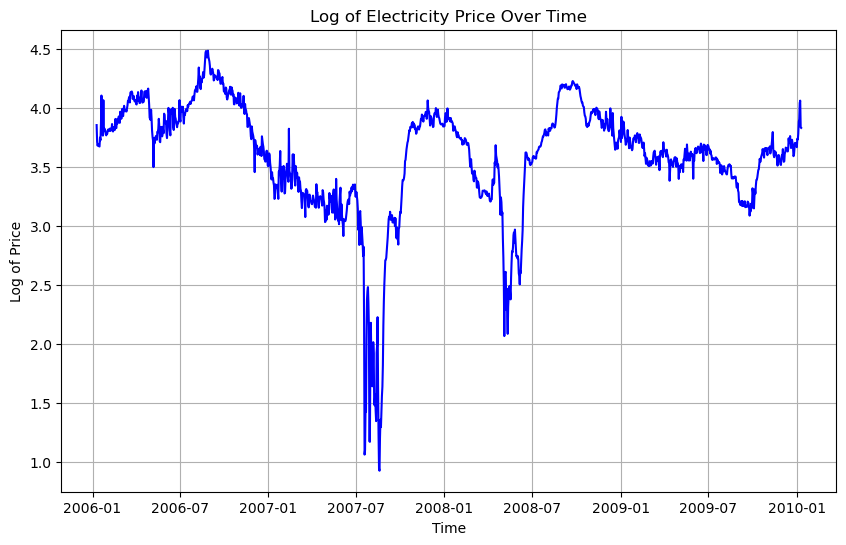

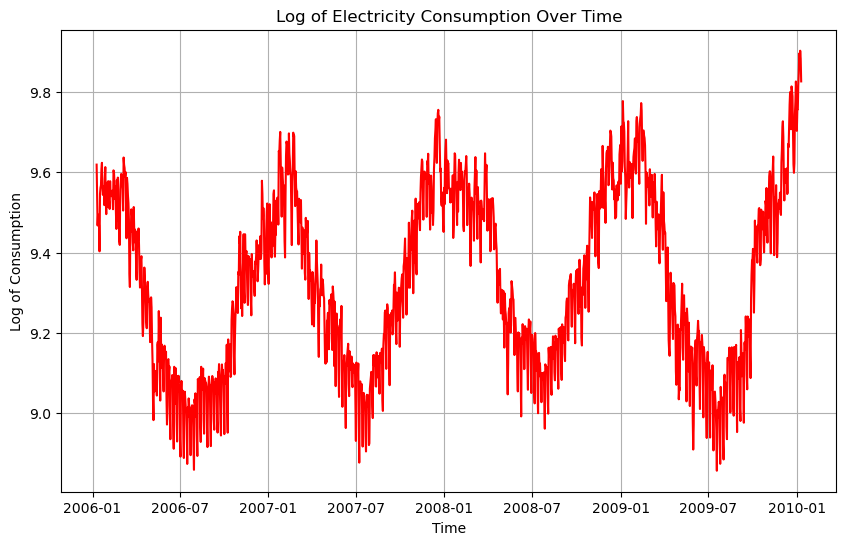

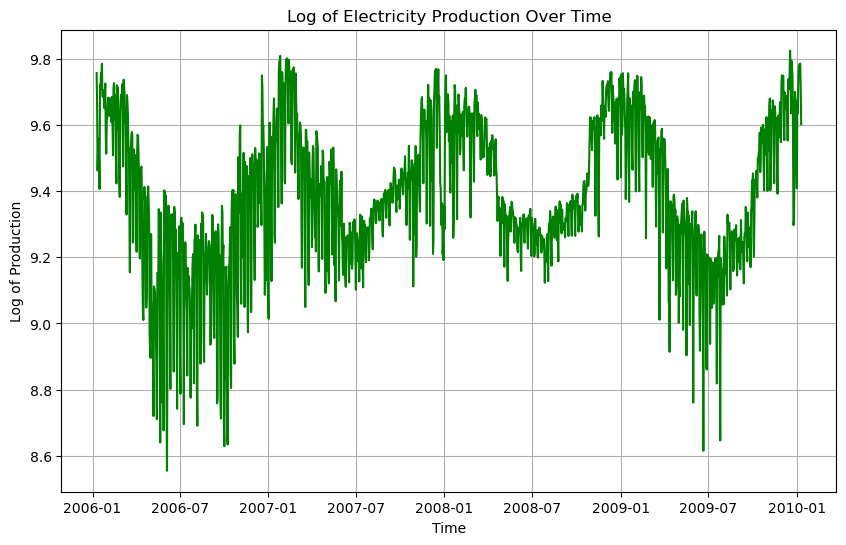

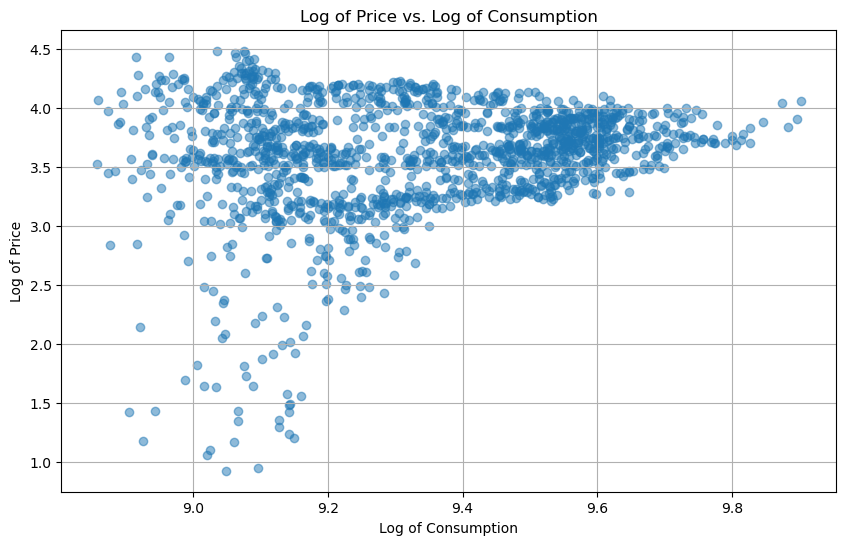

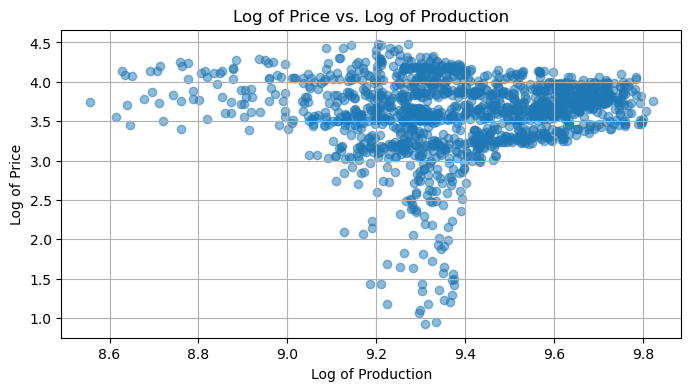

In [7]:
# Electricity Price Plot
plt.figure(figsize=(10, 6))
plt.plot(df['time'], df['log_price'], color='blue')
plt.title('Log of Electricity Price Over Time')
plt.xlabel('Time')
plt.ylabel('Log of Price')
plt.grid(True)
plt.show()

# Consumption Plot
plt.figure(figsize=(10, 6))
plt.plot(df['time'], df['log_cons'], color='red')
plt.title('Log of Electricity Consumption Over Time')
plt.xlabel('Time')
plt.ylabel('Log of Consumption')
plt.grid(True)
plt.show()

# Production Plot
plt.figure(figsize=(10, 6))
plt.plot(df['time'], df['log_prod'], color='green')
plt.title('Log of Electricity Production Over Time')
plt.xlabel('Time')
plt.ylabel('Log of Production')
plt.grid(True)
plt.show()

# Price vs. Consumption Plot
plt.figure(figsize=(10, 6))
plt.scatter(df['log_cons'], df['log_price'], alpha=0.5)
plt.title('Log of Price vs. Log of Consumption')
plt.xlabel('Log of Consumption')
plt.ylabel('Log of Price')
plt.grid(True)
plt.show()

# Price vs. Production Plot
plt.figure(figsize=(8, 4))
plt.scatter(df['log_prod'], df['log_price'], alpha=0.5)
plt.title('Log of Price vs. Log of Production')
plt.xlabel('Log of Production')
plt.ylabel('Log of Price')
plt.grid(True)
plt.show()

# Now you can discuss

# Temperature is a key driver indeed!!!

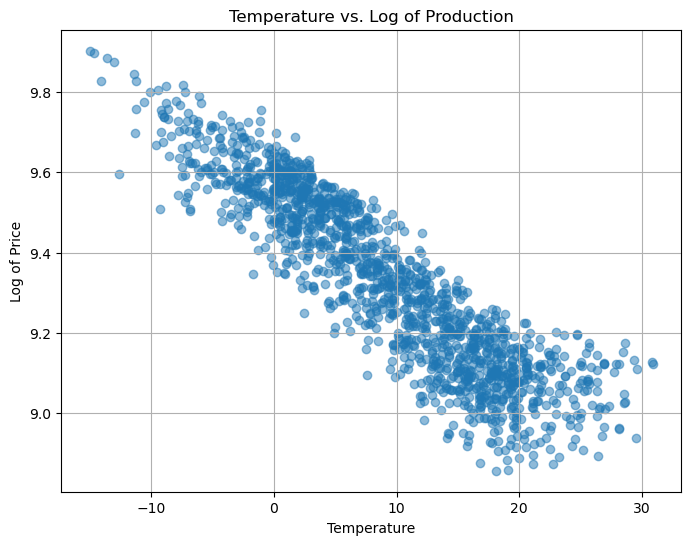

In [8]:
# Price vs. Production Plot
plt.figure(figsize=(8, 6))
plt.scatter(df['temp_osl'], df['log_cons'], alpha=0.5)
plt.title('Temperature vs. Log of Production')
plt.xlabel('Temperature')
plt.ylabel('Log of Price')
plt.grid(True)
plt.show()

In [9]:
# Creating the 'heatd' variable
df['heatd'] = 17 - df['temp_osl']
df['heatd'] = df['heatd'].apply(lambda x: x if x > 0 else 0)

# Ascertaining weekly seasonality

In [10]:
average_consumption_by_day = df.groupby(['day'])[['cons']].mean()
average_consumption_by_day

,cons
day,
1,11818.110048
2,11801.339713
3,11903.808612
4,11817.765550
5,11906.392344
6,11008.813397
7,10543.832536


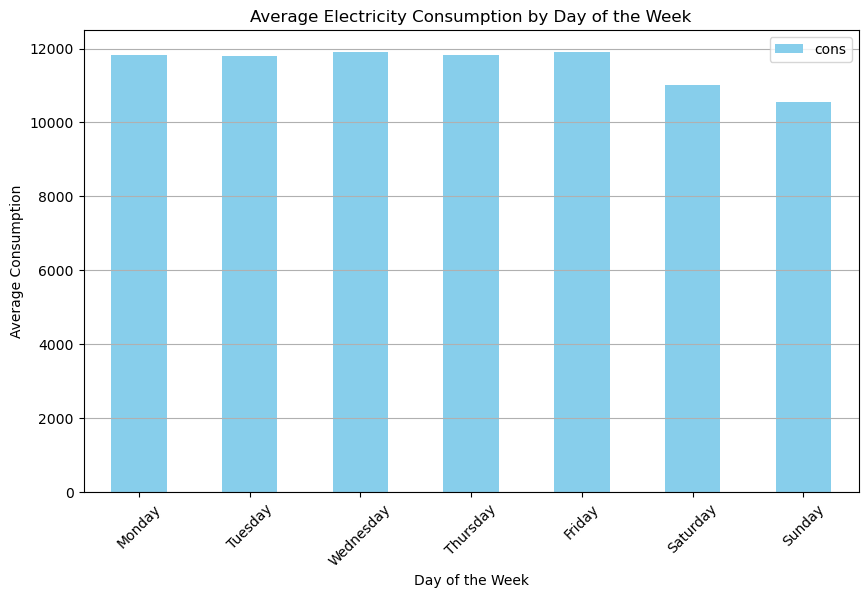

In [11]:
average_consumption_by_day.plot(kind='bar', figsize=(10, 6), color='skyblue')
plt.title('Average Electricity Consumption by Day of the Week')
plt.xlabel('Day of the Week')
plt.ylabel('Average Consumption')
plt.xticks(ticks=range(7), labels=['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday'], rotation=45)
plt.grid(axis='y')
plt.show()

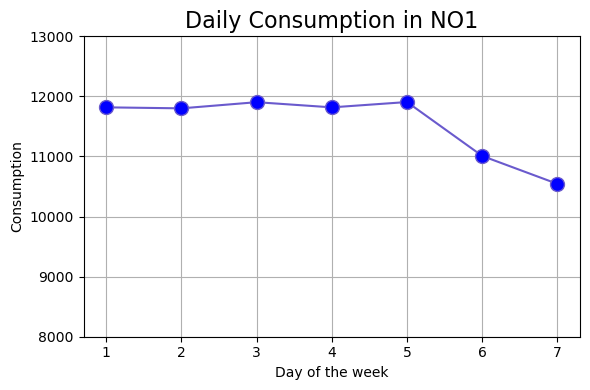

In [12]:
fig, ax = plt.subplots(figsize=(6,4))
ax.set_title('Daily Consumption in NO1',fontsize=16)
ax.plot(average_consumption_by_day['cons'],c='slateblue',marker='o',markerfacecolor='blue', markersize=10)
ax.set_xlabel('Day of the week')
ax.set_ylabel('Consumption')
ax.set_ylim(8000,13000)
ax.grid(True)
fig.tight_layout()

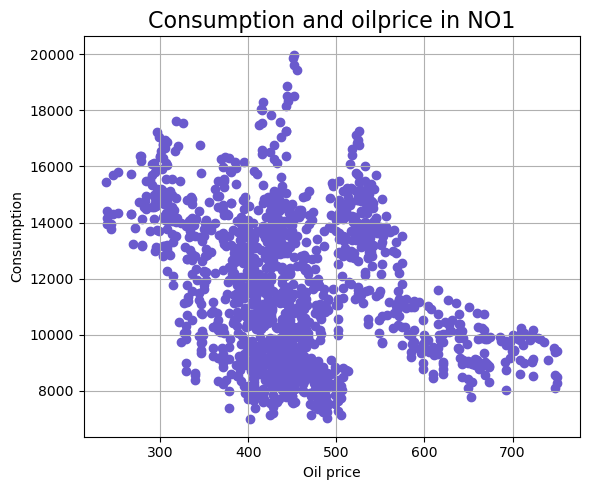

In [13]:
fig, ax = plt.subplots(figsize=(6,5))
ax.set_title('Consumption and oilprice in NO1',fontsize=16)
ax.scatter(df['p_oil'],df['cons'],c='slateblue')
ax.set_xlabel('Oil price')
ax.set_ylabel('Consumption')
ax.grid(True)
fig.tight_layout()

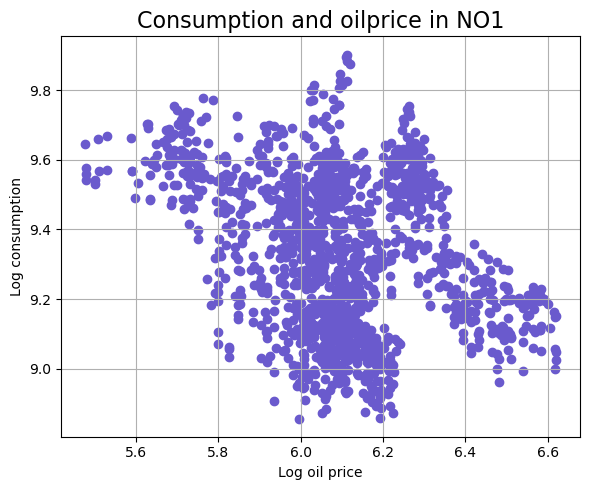

In [14]:
fig, ax = plt.subplots(figsize=(6,5))
ax.set_title('Consumption and oilprice in NO1',fontsize=16)
ax.scatter(df['ln_poil'],df['log_cons'],c='slateblue')
ax.set_xlabel('Log oil price')
ax.set_ylabel('Log consumption')
ax.grid(True)
fig.tight_layout()

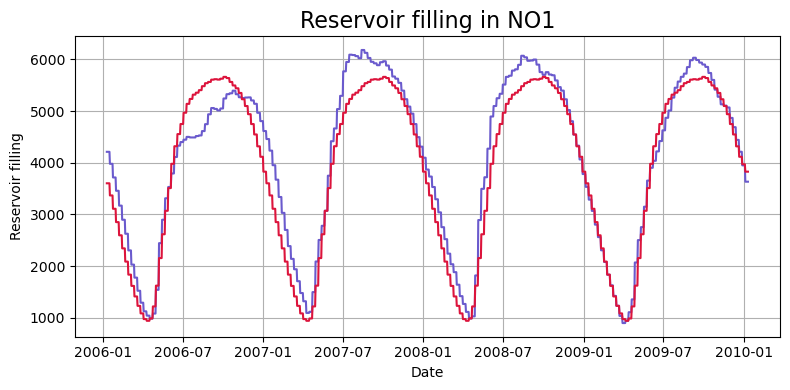

In [15]:
fig, ax = plt.subplots(figsize=(8,4))
ax.set_title('Reservoir filling in NO1',fontsize=16)
ax.plot(df['res_level'],c='slateblue')
ax.plot(df['norm_level'],c='crimson')
ax.set_xlabel('Date')
ax.set_ylabel('Reservoir filling')
ax.grid(True)
fig.tight_layout()

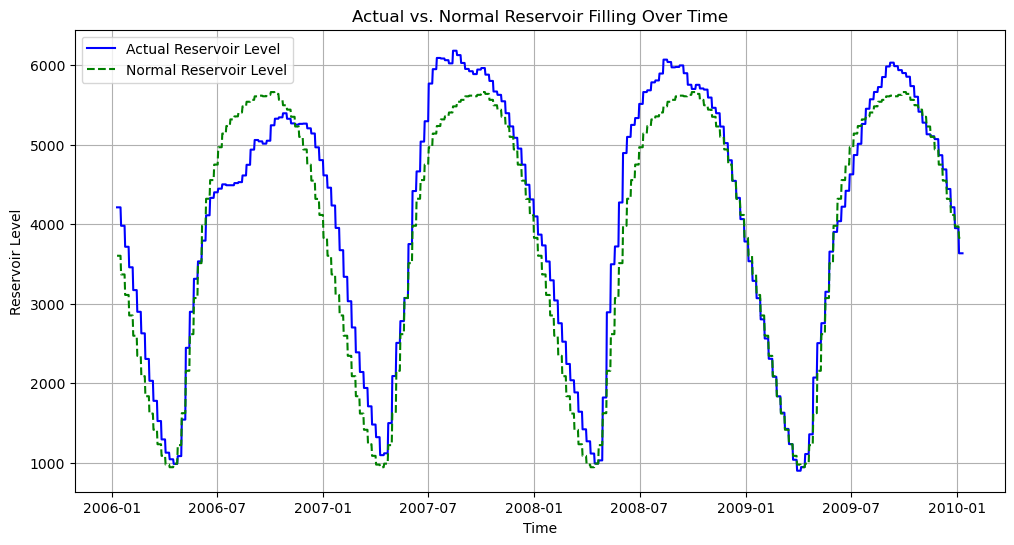

In [16]:
plt.figure(figsize=(12, 6))
plt.plot(df['time'], df['res_level'], label='Actual Reservoir Level', color='blue')
plt.plot(df['time'], df['norm_level'], label='Normal Reservoir Level', color='green', linestyle='--')
plt.title('Actual vs. Normal Reservoir Filling Over Time')
plt.xlabel('Time')
plt.ylabel('Reservoir Level')
plt.legend()
plt.grid(True)
plt.show()

In [17]:
df['rshort'] = df['res_level'] / df['norm_level']

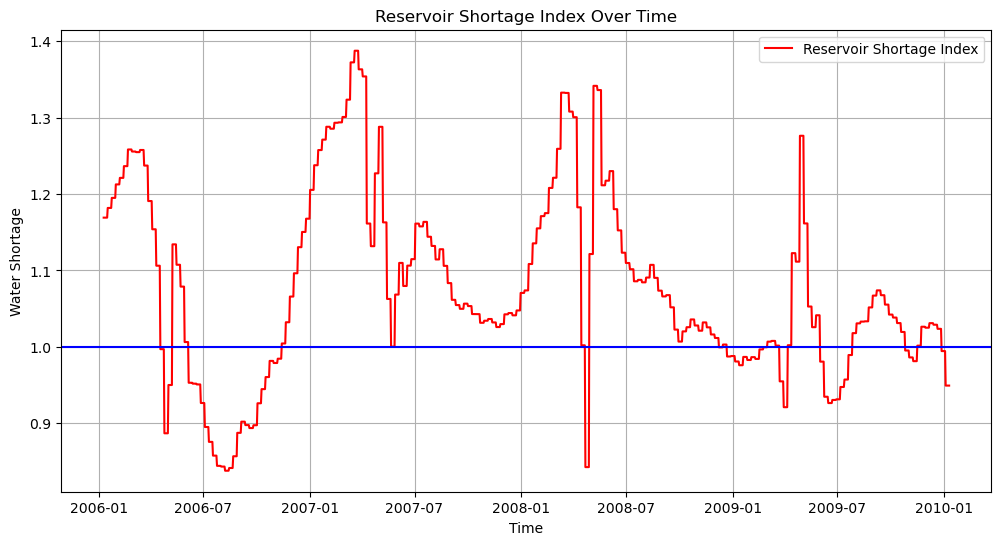

In [18]:
plt.figure(figsize=(12, 6))
plt.plot(df['time'], df['rshort'], label='Reservoir Shortage Index', color='red')
plt.title('Reservoir Shortage Index Over Time')
plt.xlabel('Time')
plt.axhline(y=1,c='blue')
plt.ylabel('Water Shortage')
plt.legend()
plt.grid(True)
plt.show()

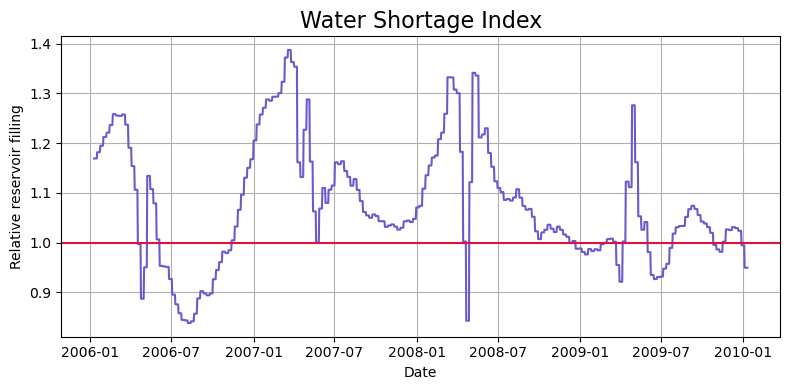

In [19]:
fig, ax = plt.subplots(figsize=(8,4))
ax.set_title('Water Shortage Index',fontsize=16)
ax.plot(df['rshort'],c='slateblue')
ax.axhline(y=1,c='crimson')
ax.set_xlabel('Date')
ax.set_ylabel('Relative reservoir filling')
ax.grid(True)
fig.tight_layout()

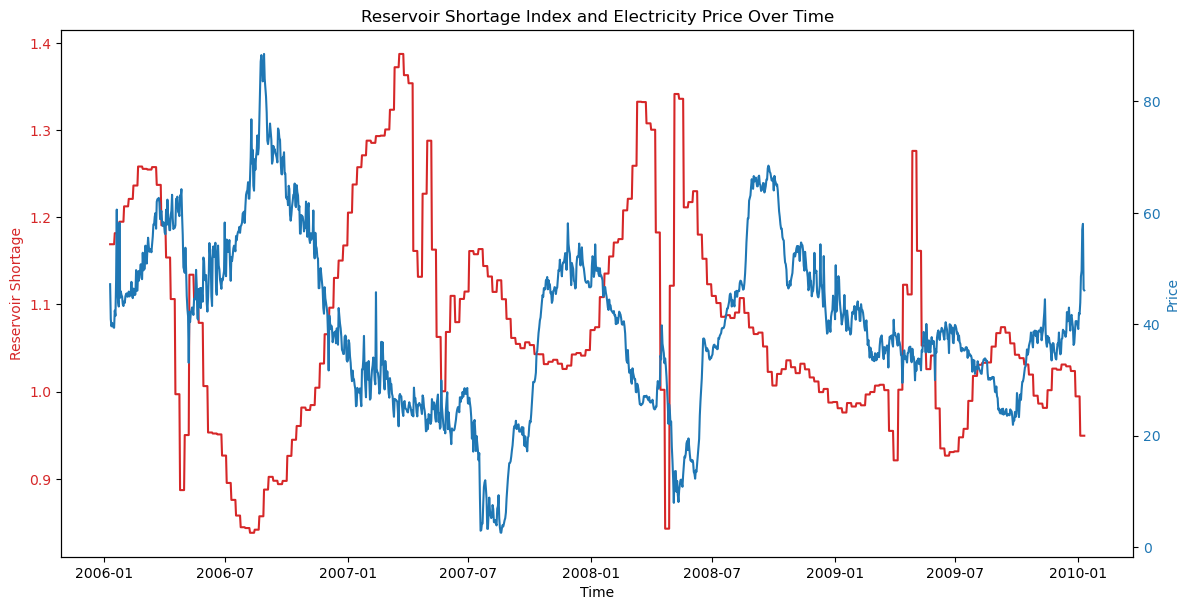

In [20]:
fig, ax1 = plt.subplots(figsize=(12, 6))

color = 'tab:red'
ax1.set_xlabel('Time')
ax1.set_ylabel('Reservoir Shortage', color=color)
ax1.plot(df['time'], df['rshort'], color=color)
ax1.tick_params(axis='y', labelcolor=color)

ax2 = ax1.twinx()
color = 'tab:blue'
ax2.set_ylabel('Price', color=color)
ax2.plot(df['time'], df['price'], color=color)
ax2.tick_params(axis='y', labelcolor=color)

fig.tight_layout()
plt.title('Reservoir Shortage Index and Electricity Price Over Time')
plt.show()


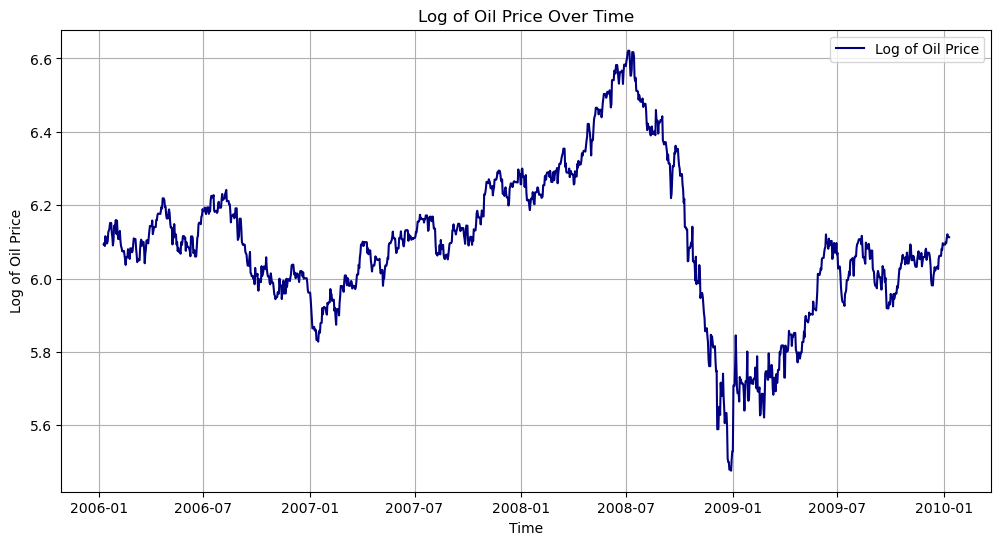

In [21]:
# Plotting for the log of oil price
plt.figure(figsize=(12, 6))
plt.plot(df['time'], df['ln_poil'], label='Log of Oil Price', color='navy')
plt.title('Log of Oil Price Over Time')
plt.xlabel('Time')
plt.ylabel('Log of Oil Price')
plt.legend()
plt.grid(True)
plt.show()

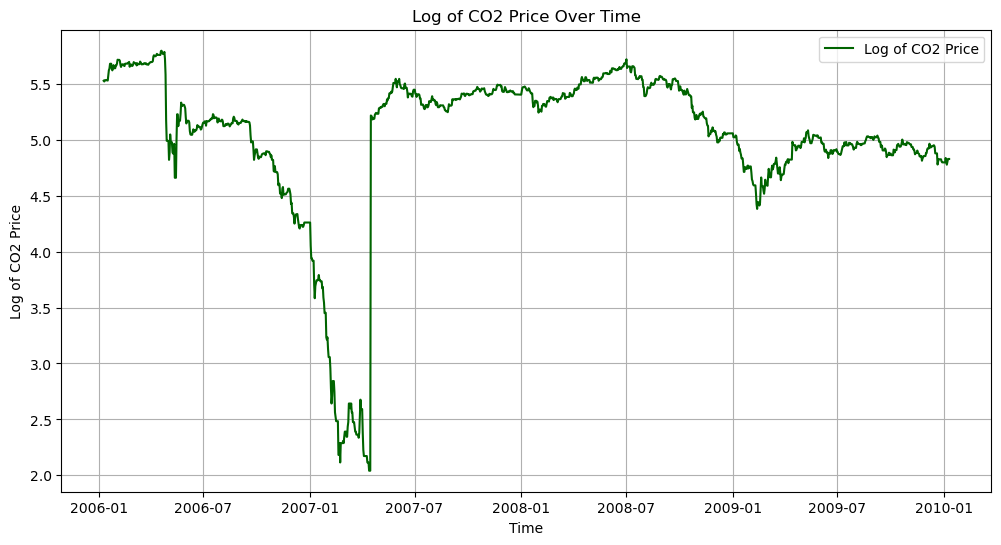

In [22]:
# Plot for the log of CO2 price
plt.figure(figsize=(12, 6))
plt.plot(df['time'], df['ln_pco2'], label='Log of CO2 Price', color='darkgreen')
plt.title('Log of CO2 Price Over Time')
plt.xlabel('Time')
plt.ylabel('Log of CO2 Price')
plt.legend()
plt.grid(True)
plt.show()


#### DEMAND

In [23]:
# OLS
olsdmod = iv.IV2SLS.from_formula(formula='log_cons ~ 1 + log_price+ heatd + ln_poil + dwkday', data=df)
olsdres = olsdmod.fit(cov_type='unadjusted')
print(olsdres)

                            OLS Estimation Summary                            
Dep. Variable:               log_cons   R-squared:                      0.8865
Estimator:                        OLS   Adj. R-squared:                 0.8862
No. Observations:                1463   F-statistic:                 1.143e+04
Date:                Thu, Apr 11 2024   P-value (F-stat)                0.0000
Time:                        18:21:24   Distribution:                  chi2(4)
Cov. Estimator:            unadjusted                                         
                                                                              
                             Parameter Estimates                              
            Parameter  Std. Err.     T-stat    P-value    Lower CI    Upper CI
------------------------------------------------------------------------------
Intercept      8.9415     0.0646     138.32     0.0000      8.8148      9.0682
log_price     -0.0227     0.0040    -5.6018     0.00

In [24]:
ivrdmod = iv.IV2SLS.from_formula(formula='log_cons ~ 1 + heatd + ln_poil + dwkday + [log_price ~ rshort + ln_pco2]',data=df)
ivrdres = ivrdmod.fit(cov_type='unadjusted')
print(ivrdres)

                          IV-2SLS Estimation Summary                          
Dep. Variable:               log_cons   R-squared:                      0.8861
Estimator:                    IV-2SLS   Adj. R-squared:                 0.8858
No. Observations:                1463   F-statistic:                 1.137e+04
Date:                Thu, Apr 11 2024   P-value (F-stat)                0.0000
Time:                        18:21:24   Distribution:                  chi2(4)
Cov. Estimator:            unadjusted                                         
                                                                              
                             Parameter Estimates                              
            Parameter  Std. Err.     T-stat    P-value    Lower CI    Upper CI
------------------------------------------------------------------------------
Intercept      8.9688     0.0673     133.30     0.0000      8.8370      9.1007
heatd          0.0273     0.0003     91.101     0.00

#### SUPPLY

In [25]:
# OLS
olssmod = iv.IV2SLS.from_formula(formula='log_price ~ 1 + rshort + ln_poil + ln_pco2 + log_cons', data=df)
olssres = olssmod.fit(cov_type='unadjusted')
print(olssres)

                            OLS Estimation Summary                            
Dep. Variable:              log_price   R-squared:                      0.2864
Estimator:                        OLS   Adj. R-squared:                 0.2845
No. Observations:                1463   F-statistic:                    587.28
Date:                Thu, Apr 11 2024   P-value (F-stat)                0.0000
Time:                        18:21:24   Distribution:                  chi2(4)
Cov. Estimator:            unadjusted                                         
                                                                              
                             Parameter Estimates                              
            Parameter  Std. Err.     T-stat    P-value    Lower CI    Upper CI
------------------------------------------------------------------------------
Intercept     -4.2035     0.7018    -5.9893     0.0000     -5.5790     -2.8279
rshort        -2.3117     0.1053    -21.961     0.00

In [26]:
ivrsmod = iv.IV2SLS.from_formula(formula='log_price ~ 1 + rshort + ln_poil + ln_pco2 + [log_cons ~ heatd + dwkday]', data=df)
ivrsres = ivrsmod.fit(cov_type='unadjusted')
print(ivrsres)

                          IV-2SLS Estimation Summary                          
Dep. Variable:              log_price   R-squared:                      0.2782
Estimator:                    IV-2SLS   Adj. R-squared:                 0.2762
No. Observations:                1463   F-statistic:                    668.40
Date:                Thu, Apr 11 2024   P-value (F-stat)                0.0000
Time:                        18:21:24   Distribution:                  chi2(4)
Cov. Estimator:            unadjusted                                         
                                                                              
                             Parameter Estimates                              
            Parameter  Std. Err.     T-stat    P-value    Lower CI    Upper CI
------------------------------------------------------------------------------
Intercept     -6.7290     0.7488    -8.9858     0.0000     -8.1967     -5.2613
rshort        -2.4486     0.1067    -22.941     0.00

#### First stage and test for demand

In [27]:
# first stage equation
fsdmod = smf.ols(formula='log_price ~ heatd + dwkday + ln_poil + rshort + ln_pco2',
                 data=df)
fsdres = fsdmod.fit(cov_type='HC3')
fsdtab = pd.DataFrame({'b'   : round(fsdres.params,4),
                       'se'  : round(fsdres.bse, 4),
                       't'   : round(fsdres.tvalues, 2),
                       'pval': round(fsdres.pvalues,4)})
print(fsdtab)

                b      se      t    pval
Intercept  2.6078  0.2992   8.71  0.0000
heatd      0.0285  0.0019  14.82  0.0000
dwkday     0.0614  0.0235   2.61  0.0091
ln_poil    0.5795  0.0668   8.67  0.0000
rshort    -2.3788  0.1218 -19.53  0.0000
ln_pco2   -0.0563  0.0155  -3.64  0.0003


In [28]:
# do an F-test of weak instruments
wihyp  = ['rshort=0','ln_pco2=0']
witest = fsdres.f_test(wihyp)

print('Test for weak instruments')
print('F-stat : {}'.format(witest.statistic))
print('p-value: {}'.format(witest.pvalue))

Test for weak instruments
F-stat : 376.33215253830883
p-value: 1.73210338241875e-132


# Relevant instruments? OK

In [29]:
#
# first stage equation
fssmod = smf.ols(formula='log_prod ~ heatd + dwkday + ln_poil + rshort + ln_pco2',
                 data=df)
fssres = fssmod.fit(cov_type='HC3')
fsstab = pd.DataFrame({'b'   : round(fssres.params,4),
                       'se'  : round(fssres.bse, 4),
                       't'   : round(fssres.tvalues, 2),
                       'pval': round(fssres.pvalues,4)})
print(fsstab)

                b      se       t    pval
Intercept  8.8607  0.0875  101.31  0.0000
heatd      0.0204  0.0004   49.50  0.0000
dwkday     0.1921  0.0082   23.45  0.0000
ln_poil   -0.0387  0.0170   -2.28  0.0228
rshort     0.3058  0.0286   10.69  0.0000
ln_pco2    0.0241  0.0051    4.74  0.0000


In [30]:
#
# do an F-test of weak instruments
wihyp  = ['heatd=0','dwkday=0']
witest = fssres.f_test(wihyp)

print('Test for weak instruments')
print('F-stat : {}'.format(witest.statistic))
print('p-value: {}'.format(witest.pvalue))

Test for weak instruments
F-stat : 1335.5223688886767
p-value: 0.0


#### Relevant? Weak?

#### Test for endogeneity

In [31]:
# demand equation results in ivrdres

ivrdres.wooldridge_regression

Wooldridge's regression test of exogeneity
H0: Endogenous variables are exogenous
Statistic: 2.2610
P-value: 0.1327
Distributed: chi2(1)
WaldTestStatistic, id: 0x238c70ede90

In [32]:
# demand equation results in ivrdres

ivrsres.wooldridge_regression

Wooldridge's regression test of exogeneity
H0: Endogenous variables are exogenous
Statistic: 110.9972
P-value: 0.0000
Distributed: chi2(1)
WaldTestStatistic, id: 0x238c70c7490

#### Test for Validity

In [33]:
# demand equation results in ivrdres

ivrdres.wooldridge_overid

Wooldridge's score test of overidentification
H0: Model is not overidentified.
Statistic: 2.1242
P-value: 0.1450
Distributed: chi2(1)
WaldTestStatistic, id: 0x238c7048e90

In [34]:
# demand equation results in ivrdres

ivrsres.wooldridge_overid

Wooldridge's score test of overidentification
H0: Model is not overidentified.
Statistic: 3.8691
P-value: 0.0492
Distributed: chi2(1)
WaldTestStatistic, id: 0x238c711e7d0

#### Heteroskedasticity

In [35]:
#
# test for heteroskedasticity for demand
df['ud_sqr'] = ivrdres.resids ** 2
bphmod = smf.ols(formula='ud_sqr ~ heatd + dwkday + ln_poil + rshort + ln_pco2', 
                 data=df)
bphres = bphmod.fit()
print('Breusch-Pagan F-test: {}'.format(round(bphres.fvalue,4)))
print('             p-value: {}'.format(round(bphres.f_pvalue,4)))

Breusch-Pagan F-test: 4.2265
             p-value: 0.0008


In [36]:
#
# test for heteroskedasticity for supply
df['us_sqr'] = ivrsres.resids ** 2
bphmod = smf.ols(formula='us_sqr ~ heatd + dwkday + ln_poil + rshort + ln_pco2', 
                 data=df)
bphres = bphmod.fit()
print('Breusch-Pagan F-test: {}'.format(round(bphres.fvalue,4)))
print('             p-value: {}'.format(round(bphres.f_pvalue,4)))

Breusch-Pagan F-test: 22.3204
             p-value: 0.0


#### Reject the null... Lets revise with GMM

In [37]:
# Demand GMM
gmmdmod = iv.IVGMM.from_formula(formula='log_cons ~ 1 + heatd + dwkday + ln_poil + [log_price ~ rshort + ln_pco2]'
                               ,weight_type='robust',data=df)
gmmdres = gmmdmod.fit(cov_type='robust')
print(gmmdres.summary)

                          IV-GMM Estimation Summary                           
Dep. Variable:               log_cons   R-squared:                      0.8862
Estimator:                     IV-GMM   Adj. R-squared:                 0.8858
No. Observations:                1463   F-statistic:                 1.022e+04
Date:                Thu, Apr 11 2024   P-value (F-stat)                0.0000
Time:                        18:21:24   Distribution:                  chi2(4)
Cov. Estimator:                robust                                         
                                                                              
                             Parameter Estimates                              
            Parameter  Std. Err.     T-stat    P-value    Lower CI    Upper CI
------------------------------------------------------------------------------
Intercept      8.9675     0.0617     145.27     0.0000      8.8465      9.0885
heatd          0.0273     0.0003     83.542     0.00

In [38]:
#
# test for valid instruments
print(gmmdres.j_stat)

H0: Expected moment conditions are equal to 0
Statistic: 2.1242
P-value: 0.1450
Distributed: chi2(1)


In [39]:
# summary of demand results
print(iv.compare({'OLS': olsdres, 'IV': ivrdres, 'GMM': gmmdres}))

                        Model Comparison                        
                                OLS             IV           GMM
----------------------------------------------------------------
Dep. Variable              log_cons       log_cons      log_cons
Estimator                       OLS        IV-2SLS        IV-GMM
No. Observations               1463           1463          1463
Cov. Est.                unadjusted     unadjusted        robust
R-squared                    0.8865         0.8861        0.8862
Adj. R-squared               0.8862         0.8858        0.8858
F-statistic               1.143e+04      1.137e+04     1.022e+04
P-value (F-stat)             0.0000         0.0000        0.0000
==================     ============   ============   ===========
Intercept                    8.9415         8.9688        8.9675
                           (138.32)       (133.30)      (145.27)
log_price                   -0.0227        -0.0323       -0.0314
                         

In [40]:
# Supply GMM
gmmsmod = iv.IVGMM.from_formula(formula='log_price ~ 1 + rshort + ln_pco2 + ln_poil + [log_prod ~ heatd + dwkday]',
                                weight_type='robust',data=df)
gmmsres = gmmsmod.fit(cov_type='robust')
print(gmmsres.summary)

                          IV-GMM Estimation Summary                           
Dep. Variable:              log_price   R-squared:                      0.1508
Estimator:                     IV-GMM   Adj. R-squared:                 0.1485
No. Observations:                1463   F-statistic:                    660.68
Date:                Thu, Apr 11 2024   P-value (F-stat)                0.0000
Time:                        18:21:24   Distribution:                  chi2(4)
Cov. Estimator:                robust                                         
                                                                              
                             Parameter Estimates                              
            Parameter  Std. Err.     T-stat    P-value    Lower CI    Upper CI
------------------------------------------------------------------------------
Intercept     -6.3894     0.9376    -6.8150     0.0000     -8.2270     -4.5519
rshort        -2.4431     0.1380    -17.710     0.00

In [41]:
#
# test for valid instruments
print(gmmsres.j_stat)

H0: Expected moment conditions are equal to 0
Statistic: 41.8476
P-value: 0.0000
Distributed: chi2(1)


In [42]:
# summary of demand results
print(iv.compare({'OLS': olssres, 'IV': ivrsres, 'GMM': gmmsres}))

                        Model Comparison                        
                                OLS             IV           GMM
----------------------------------------------------------------
Dep. Variable             log_price      log_price     log_price
Estimator                       OLS        IV-2SLS        IV-GMM
No. Observations               1463           1463          1463
Cov. Est.                unadjusted     unadjusted        robust
R-squared                    0.2864         0.2782        0.1508
Adj. R-squared               0.2845         0.2762        0.1485
F-statistic                  587.28         668.40        660.68
P-value (F-stat)             0.0000         0.0000        0.0000
==================     ============   ============   ===========
Intercept                   -4.2035        -6.7290       -6.3894
                          (-5.9893)      (-8.9858)     (-6.8150)
rshort                      -2.3117        -2.4486       -2.4431
                         

## 8

### DEMAND CURVES

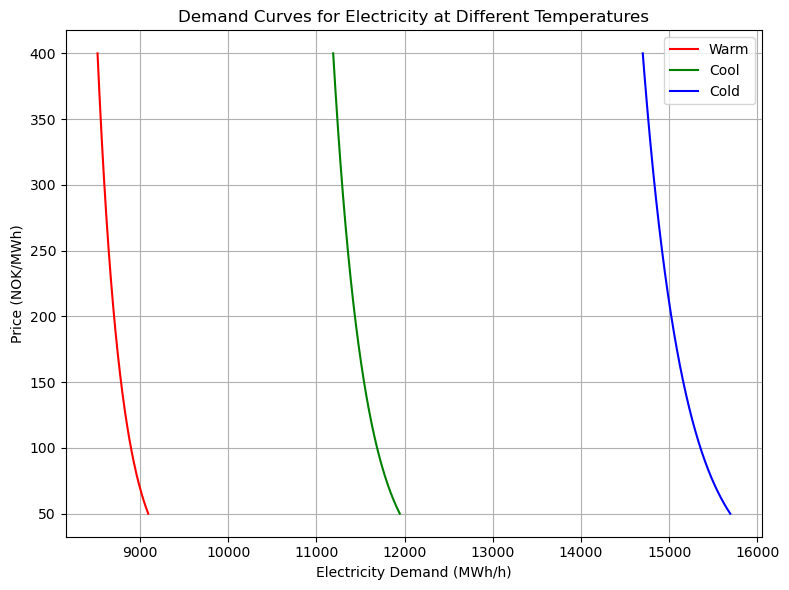

In [43]:

dbeta = gmmdres.params

# Setting up scenario parameters
oil_price = 500  # Oil price in NOK
co2_price = 250  # CO2 permits price in NOK
ln_oil_price = np.log(oil_price)  # Log-transformed oil price
ln_co2_price = np.log(co2_price)  # Log-transformed CO2 price

# Calculating the demand at different prices for various temperature conditions
prices = np.linspace(50, 400, 200)  # Range of prices
ln_prices = np.log(prices)  # Log-transformed prices for the model

# Calculating demands for different scenarios
warm = np.exp(dbeta['Intercept'] + dbeta['log_price']*ln_prices + dbeta['dwkday'] + dbeta['ln_poil']*ln_oil_price)
cool = np.exp(dbeta['Intercept'] + dbeta['heatd']*10 + dbeta['log_price']*ln_prices + dbeta['dwkday'] + dbeta['ln_poil']*ln_oil_price)
cold = np.exp(dbeta['Intercept'] + dbeta['heatd']*20 + dbeta['log_price']*ln_prices + dbeta['dwkday'] + dbeta['ln_poil']*ln_oil_price)

# Plotting
fig, ax = plt.subplots(figsize=(8, 6))

# Swapping the axes: now y-axis is for demand and x-axis is for price
ax.plot(warm, prices, label='Warm', color='red')
ax.plot(cool, prices, label='Cool', color='green')
ax.plot(cold, prices, label='Cold', color='blue')

# Setting labels and titles
ax.set_ylabel('Price (NOK/MWh)')
ax.set_xlabel('Electricity Demand (MWh/h)')
ax.set_title('Demand Curves for Electricity at Different Temperatures')
ax.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

#### SUPPLY CURVES

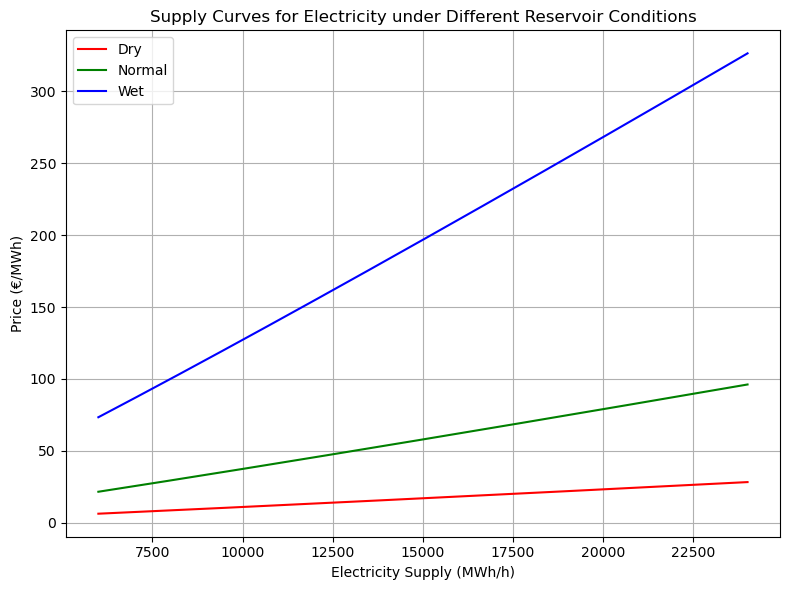

In [44]:

# Use the GMM model parameters for supply
sbeta = gmmsres.params

# Defining reservoir conditions with rshort values for dry, normal, and wet scenarios
rshort_values = {'Dry': 1.5, 'Normal': 1.0, 'Wet': 0.5}
# Corresponding colors for each scenario
colors = {'Dry': 'red', 'Normal': 'green', 'Wet': 'blue'}

# Generating a range of electricity supply quantities
supply_quantities = np.linspace(6000, 24000, 200)  
ln_supply_quantities = np.log(supply_quantities)  
# Plotting setup
fig, ax = plt.subplots(figsize=(8, 6))

# Calculating and plot supply curves for each reservoir condition
for condition, rshort in rshort_values.items():
    price = np.exp(sbeta['Intercept'] + sbeta['rshort'] * rshort +
                   sbeta['ln_pco2'] * ln_co2_price + sbeta['ln_poil'] * ln_oil_price +
                   sbeta['log_prod'] * ln_supply_quantities) 

    # getting the corresponding color of our choice
    color = colors[condition]
    ax.plot(supply_quantities, price, label=condition, color=color)

# Setting labels and titles
ax.set_xlabel('Electricity Supply (MWh/h)')
ax.set_ylabel('Price (€/MWh)')
ax.set_title('Supply Curves for Electricity under Different Reservoir Conditions')
ax.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


#### 8.3

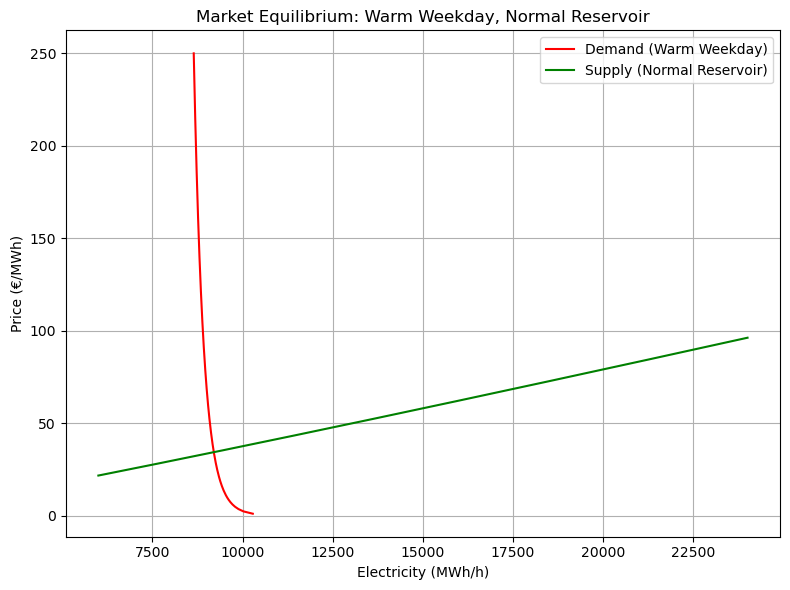

In [45]:

# Demand scenarios (warm, cool, cold) and Supply scenarios (Dry, Normal, Wet)
prices = np.linspace(1, 250, 200)
ln_prices = np.log(prices)
supply_quantities = np.linspace(6000, 24000, 200)
ln_supply_quantities = np.log(supply_quantities)

# Demand for a warm weekday
warm_demand = np.exp(dbeta['Intercept'] + dbeta['log_price']*ln_prices + dbeta['dwkday'] + dbeta['ln_poil']*ln_oil_price)

# Supply for normal reservoir filling
normal_supply_price = np.exp(sbeta['Intercept'] + sbeta['rshort'] * 1.0 + sbeta['ln_pco2'] * ln_co2_price + sbeta['ln_poil'] * ln_oil_price + sbeta['log_prod'] * ln_supply_quantities)

# Plotting
fig, ax = plt.subplots(figsize=(8, 6))

# Demand curve
ax.plot(warm_demand, prices, label='Demand (Warm Weekday)', color='red')

# Supply curve for normal reservoir
ax.plot(supply_quantities, normal_supply_price, label='Supply (Normal Reservoir)', color='green')

# Annotations and labels
ax.set_xlabel('Electricity (MWh/h)')
ax.set_ylabel('Price (€/MWh)')
ax.set_title('Market Equilibrium: Warm Weekday, Normal Reservoir')
ax.legend()
plt.grid(True)
plt.tight_layout()
plt.show()
